# Flere tester: ikke-parametriske tester og kijikvadrat
*Data Mining & Analytics – Samling 2, dag 1*

Hvilken test skal jeg bruke? 

Det avhenger av datatype, antall grupper og om observasjonene er parvise.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)
rng = np.random.default_rng(42)   # fast seed => samme resultater hver gang

In [3]:
pingvin = pd.read_csv("../Data/penguins.csv").dropna()

## Mann–Whitney U – når dataene er skjeve (kontinuerlige data)

Med kraftig skjeve data (og små utvalg) er medianen mer representativ enn gjennomsnittet, og rangbaserte tester er tryggere.

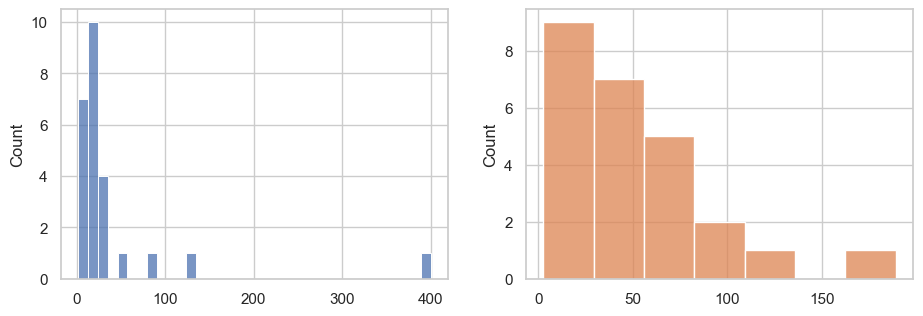

Welch t-test : 0.5414
Mann–Whitney : 0.0079
t-test på log-verdier: 0.0301


In [ ]:
rng = np.random.default_rng(3)
a = rng.lognormal(3.0, 0.9, 25)      # f.eks. ventetid, gruppe A
b = rng.lognormal(3.5, 0.9, 25)      # gruppe B (sann forskyvning)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(a, ax=ax[0])
sns.histplot(b, ax=ax[1], color="C1")
plt.show()

print("Welch t-test :", stats.ttest_ind(b, a, equal_var=False).pvalue.round(4))
print("Mann–Whitney :", stats.mannwhitneyu(b, a, alternative="two-sided").pvalue.round(4))
print("t-test på log-verdier:", stats.ttest_ind(np.log(b), np.log(a)).pvalue.round(4))

## χ²-test for uavhengighet (kategoriske data)

Er kjønn og art uavhengige? Sammenligner observerte med forventede antall under uavhengighet.

In [5]:
kryss = pd.crosstab(pingvin["species"], pingvin["sex"])
print(kryss)
chi2, p, dof, forventet = stats.chi2_contingency(kryss)
print(f"\nχ² = {chi2:.2f}, df = {dof}, p = {p:.3f}")
print("Forventede antall:\n", pd.DataFrame(forventet, index=kryss.index, columns=kryss.columns).round(1))

sex        FEMALE  MALE
species                
Adelie         73    73
Chinstrap      34    34
Gentoo         58    61

χ² = 0.05, df = 2, p = 0.976
Forventede antall:
 sex        FEMALE  MALE
species                
Adelie       72.3  73.7
Chinstrap    33.7  34.3
Gentoo       59.0  60.0


In [1]:
# Sterk sammenheng: art og øy
kryss2 = pd.crosstab(pingvin["species"], pingvin["island"])
chi2, p, dof, _ = stats.chi2_contingency(kryss2)
print(f"art x øy: χ² = {chi2:.1f}, p = {p:.1e}")

# Fisher exact for 2x2 med små tall
tabell = np.array([[8, 2], [1, 5]])
print("Fisher exact (små tall):", stats.fisher_exact(tabell))

NameError: name 'pd' is not defined